# 1. Project Introduction

This notebook trains a CNN for EMNIST Balanced handwritten character recognition. It uses exactly 30,000 training rows and 10,000 testing rows, then saves the model used by `app.py`.

# 2. Import Libraries

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import NUM_CLASSES, load_emnist, load_mapping

# 3. Load EMNIST Dataset

In [15]:
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data" / "emnist-balanced.mat"
MAPPING_PATH = ROOT / "data" / "emnist-balanced-mapping.txt"
MODEL_PATH = ROOT / "model" / "emnist_balanced_cnn.keras"

train_images, train_labels, test_images, test_labels = load_emnist(DATA_PATH, 30_000, 10_000)
labels = load_mapping(MAPPING_PATH)
print(f"Loaded {len(train_images):,} training rows and {len(test_images):,} testing rows.")

Loaded 30,000 training rows and 10,000 testing rows.


# 4. Explore Dataset

Training images: (30000, 28, 28, 1)
Testing images: (10000, 28, 28, 1)
Classes: 47


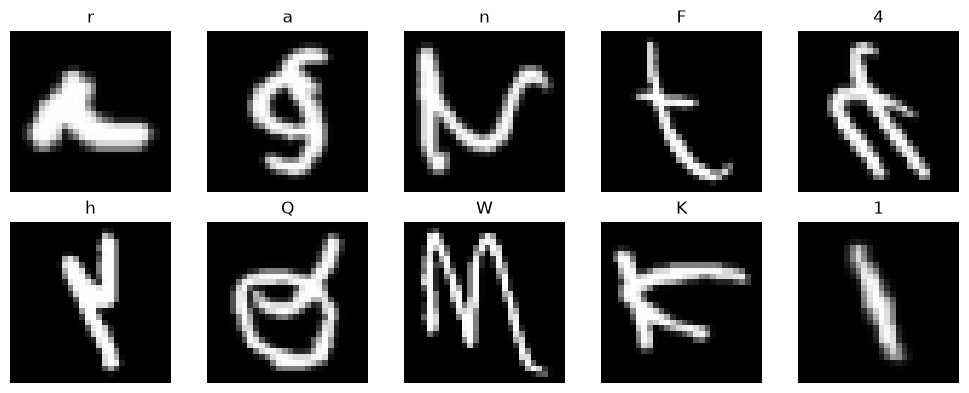

In [3]:
print("Training images:", train_images.shape)
print("Testing images:", test_images.shape)
print("Classes:", len(labels))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis, image, label in zip(axes.ravel(), train_images[:10], train_labels[:10]):
    axis.imshow(image[..., 0], cmap="gray")
    axis.set_title(labels[int(label)])
    axis.axis("off")
plt.tight_layout()

# 5. Preprocess Images

In [16]:
train_images = train_images.astype("float32")
test_images = test_images.astype("float32")
assert train_images.min() >= 0 and train_images.max() <= 1
assert test_images.min() >= 0 and test_images.max() <= 1
print("Images are upright, normalized, and shaped as 28x28x1 tensors.")

Images are upright, normalized, and shaped as 28x28x1 tensors.


# 6. Select Training & Testing Data

In [17]:
assert train_images.shape == (30_000, 28, 28, 1)
assert train_labels.shape == (30_000,)
assert test_images.shape == (10_000, 28, 28, 1)
assert test_labels.shape == (10_000,)
print("Training rows: 30,000")
print("Testing rows: 10,000")

Training rows: 30,000
Testing rows: 10,000


# 7. Build CNN Model

In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.RandomRotation(0.04, fill_mode="constant"),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_1               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,807 (897.68 KB)

 Trainable params: 229,807 (897.68 KB)

 Non-trainable params: 0 (0.00 B)

# 8. Compile Model

In [19]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# 9. Train Model

In [23]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        mode="max",
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model.fit(
    train_images,
    train_labels,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8652 - loss: 0.3826 - val_accuracy: 0.8517 - val_loss: 0.4321 - learning_rate: 0.0010
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8669 - loss: 0.3756 - val_accuracy: 0.8543 - val_loss: 0.4335 - learning_rate: 0.0010
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8698 - loss: 0.3622 - val_accuracy: 0.8543 - val_loss: 0.4272 - learning_rate: 0.0010
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8715 - loss: 0.3515 - val_accuracy: 0.8527 - val_loss: 0.4259 - learning_rate: 0.0010
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8722 - loss: 0.3467 - val_accuracy: 0.8530 - val_loss: 0.4273 - learning_rate: 0.0010
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8793 - loss: 0.3348 - val_accuracy: 0.8583 - val_loss: 0.4304 - learning_rate: 0.0010
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8887 - loss: 0.

# 10. Plot Training Results

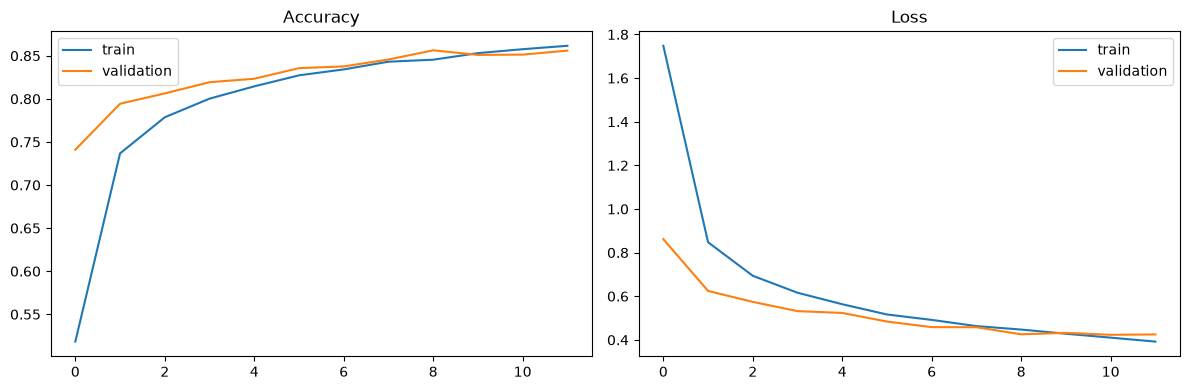

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("Accuracy")
axes[0].legend()
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Loss")
axes[1].legend()
plt.tight_layout()

# 11. Evaluate Model

In [24]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test loss: 0.4214
Test accuracy: 86.64%


# 12. Confusion Matrix

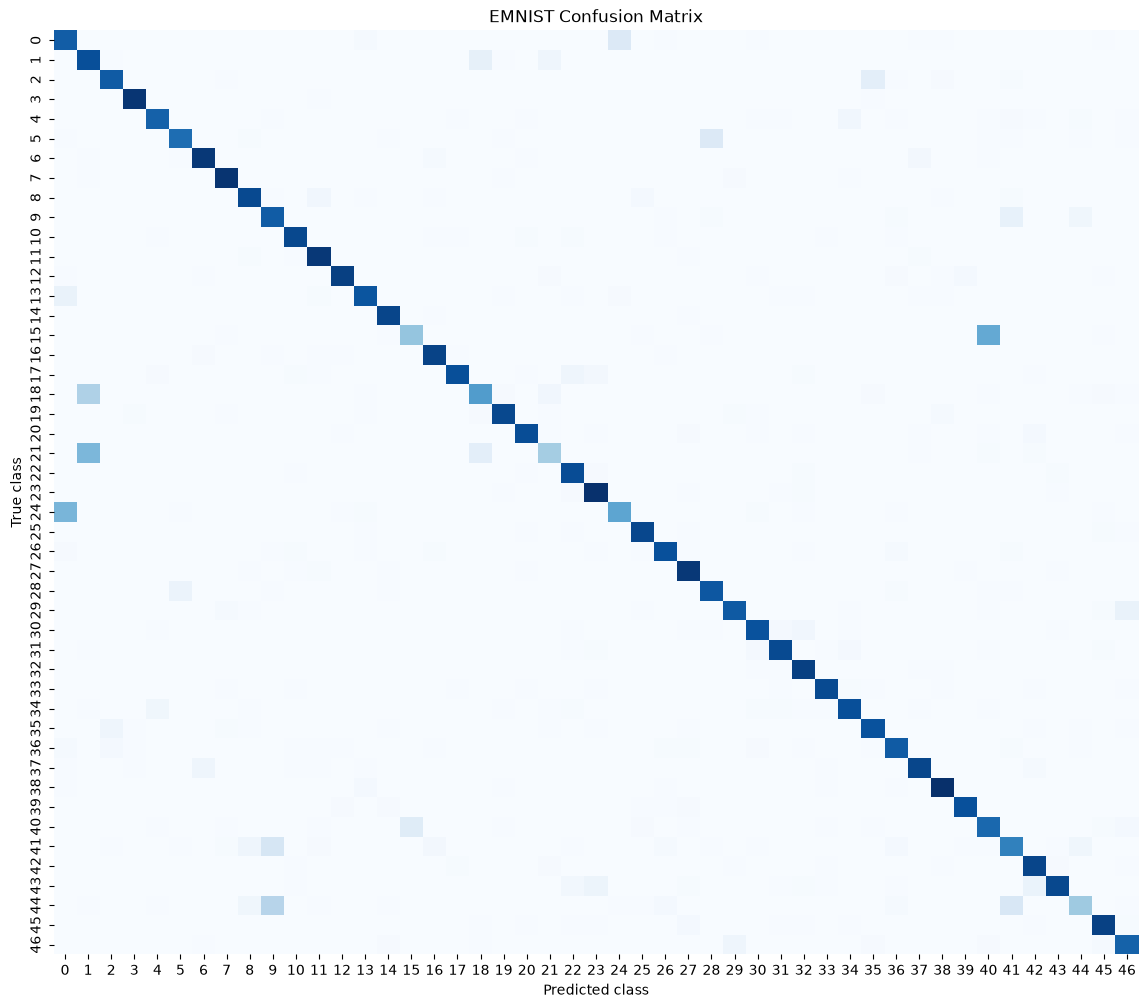

In [10]:
test_predictions = model.predict(test_images, verbose=0).argmax(axis=1)
matrix = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(14, 12))
sns.heatmap(matrix, cmap="Blues", cbar=False)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("EMNIST Confusion Matrix")
plt.show()

# 13. Classification Report

In [11]:
class_names = [labels[index] for index in range(NUM_CLASSES)]
print(classification_report(test_labels, test_predictions, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

           0       0.58      0.82      0.68       218
           1       0.52      0.86      0.65       222
           2       0.91      0.86      0.89       210
           3       0.98      0.99      0.98       214
           4       0.92      0.89      0.90       198
           5       0.91      0.81      0.86       205
           6       0.93      0.94      0.94       224
           7       0.94      0.97      0.96       219
           8       0.88      0.91      0.89       215
           9       0.63      0.85      0.72       211
           A       0.94      0.95      0.95       207
           B       0.91      0.97      0.94       216
           C       0.97      0.93      0.95       220
           D       0.92      0.87      0.89       213
           E       0.94      0.99      0.97       202
           F       0.77      0.42      0.54       204
           G       0.93      0.96      0.94       209
           H       0.97    

# 14. Test Sample Predictions

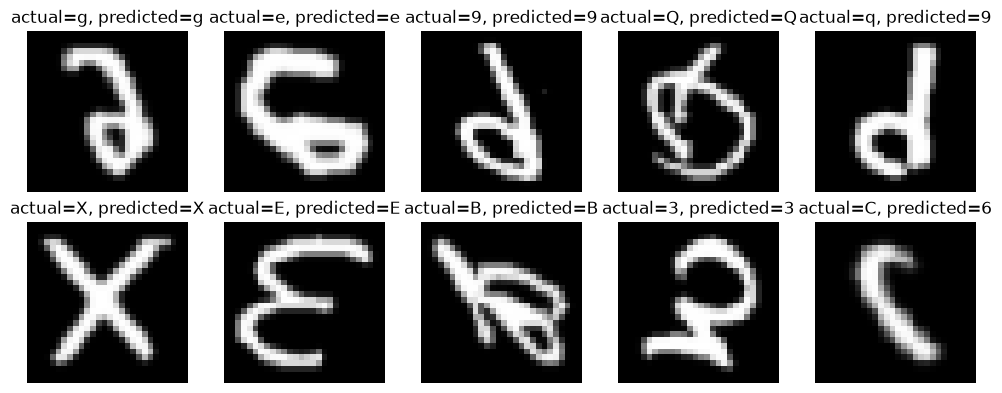

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis, image, actual, predicted in zip(axes.ravel(), test_images[:10], test_labels[:10], test_predictions[:10]):
    axis.imshow(image[..., 0], cmap="gray")
    axis.set_title(f"actual={labels[int(actual)]}, predicted={labels[int(predicted)]}")
    axis.axis("off")
plt.tight_layout()

# 15. Save Trained Model

In [25]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
model.save(MODEL_PATH)
print(f"Saved model to {MODEL_PATH}")

Saved model to c:\Users\sanka\Downloads\Handwritten-Character-Recognition-using-CNN-master\Handwritten-Character-Recognition-using-CNN-master\model\emnist_balanced_cnn.keras


# 16. Final Conclusion

The CNN was trained on 30,000 upright EMNIST images, evaluated on 10,000 test images, and saved for the Streamlit upload and drawing interface.